# Generate ARIMA data example

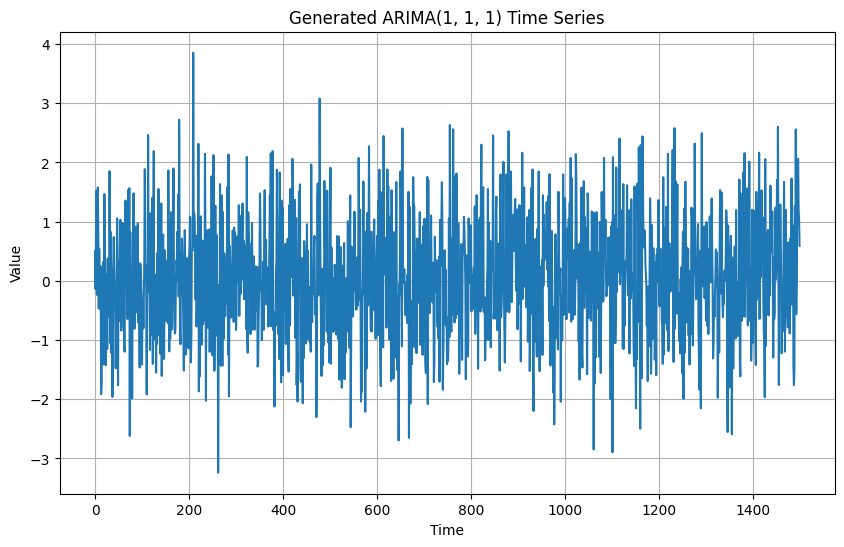

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

def generate_arima_time_series(p, d, q, length=1500):
    # Set the random seed for reproducibility
    np.random.seed(42)

    # Generate a random initial time series (white noise)
    data = np.random.randn(length)

    # Fit an ARIMA model
    model = ARIMA(data, order=(p, d, q))
    model_fit = model.fit()

    # Generate forecast
    forecast = model_fit.fittedvalues + model_fit.resid

    # Plot the generated time series
    plt.figure(figsize=(10, 6))
    plt.plot(forecast)
    plt.title(f"Generated ARIMA({p}, {d}, {q}) Time Series")
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.grid(True)
    plt.show()

    return forecast

# generate_arima_time_series
p, d, q = 1, 1, 1
arima_series = generate_arima_time_series(p, d, q)


In [ ]:
arima_series.shape

(1500,)

# Import stock data

In [ ]:
import yfinance as yf

# Define the ticker symbol for Apple Inc.
ticker_symbol = 'AAPL'

# Define the period (you can adjust the period as needed, e.g., '1y', '5y', 'max')
period = '10y'  # For 5 years of data

# Fetch the historical stock data
data = yf.download(ticker_symbol, period=period)

# Extract the 'Close' prices as a numpy array
close_data = data['Close'].values  # Converts to a numpy array
close_data = close_data[:1500]


[*********************100%***********************]  1 of 1 completed


# Create training set

In [ ]:
import numpy as np

#input_data = arima_series
input_data = close_data

# Parameters for input block size, features, and output size
block_size = 5   # Number of time steps used for input
n_features = 1   # Number of features per time step (e.g., 1 feature like stock price)
n_out = 1        # Number of time steps to predict (e.g., 5 future time steps)

# Step 1: Create the training and test sets (no validation set)
test_size = 0.15  # 15% of data for test set
train_idx = round(len(input_data) * (1 - test_size))

train_data = input_data[:train_idx]
test_data = input_data[train_idx:]

# Reshape the data to add a new axis for features
train_data = np.array(train_data)[:, np.newaxis]  # Shape: (samples, features)
test_data = np.array(test_data)[:, np.newaxis]    # Shape: (samples, features)

# Step 2: Reshape the data into samples, time steps, and features
def window_and_reshape(data, block_size, n_features):
    """
    Reformats data into shape: [# samples, timestep, # features]
    """
    samples = int(data.shape[0] / block_size)  # Calculate how many samples can be created
    result = np.array(np.array_split(data, samples))  # Split data into windows
    return result.reshape((samples, block_size, n_features))  # Reshape into (samples, timestep, features)

# Reshape the training and test data
X_train = window_and_reshape(train_data, block_size, n_features)
X_test = window_and_reshape(test_data, block_size, n_features)

#Convert the data into a supervised learning format
def to_supervised(data, n_input, n_out):
    """
    Converts time series data into a supervised learning problem.
    """
    X, y = [], []
    data = data.reshape((data.shape[0] * data.shape[1], data.shape[2]))  # Flatten the data
    in_start = 0
    for _ in range(len(data) - n_input - n_out + 1):  # Ensure we don't exceed data length
        in_end = in_start + n_input
        out_end = in_end + n_out
        x_input = data[in_start:in_end, 0]
        x_input = x_input.reshape((len(x_input), 1))
        X.append(x_input)
        y.append(data[in_end:out_end, 0])
        in_start += 1
    return np.array(X), np.array(y)

# Convert the training and test data into supervised format
X_train_supervised, y_train_supervised = to_supervised(X_train, block_size, n_out)
X_test_supervised, y_test_supervised = to_supervised(X_test, block_size, n_out)

# Shared variables after creating the sets
n_timesteps, n_features, n_outputs = X_train_supervised.shape[1], X_train_supervised.shape[2], y_train_supervised.shape[1]

# Output the shapes to confirm
print(f"X_train shape: {X_train_supervised.shape}")
print(f"y_train shape: {y_train_supervised.shape}")
print(f"X_test shape: {X_test_supervised.shape}")
print(f"y_test shape: {y_test_supervised.shape}")


X_train shape: (1270, 5, 1)
y_train shape: (1270, 1)
X_test shape: (220, 5, 1)
y_test shape: (220, 1)


#Build the LSTM

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Step 4: Create LSTM Model
def create_lstm_model(n_timesteps, n_features, n_outputs):
    callbacks = [EarlyStopping(patience=10, restore_best_weights=True)]

    model = Sequential()
    model.add(LSTM(200, activation='relu', input_shape=(n_timesteps, n_features)))
    model.add(Dense(50, activation='relu'))
    model.add(Dense(n_outputs))

    print('Compiling baseline model...')
    model.compile(optimizer='adam', loss='mse', metrics=['mae', 'mape'])

    return model

# Create the LSTM model
lstm_model = create_lstm_model(n_timesteps, n_features, n_outputs)
lstm_model.summary()


Compiling baseline model...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                       │ (None, 200)                 │         161,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_44 (Dense)                     │ (None, 50)                  │          10,050 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_45 (Dense)                     │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 171,701 (670.71 KB)

 Trainable params: 171,701 (670.71 KB)

 Non-trainable params: 0 (0.00 B)

# Build the transformer model

In [ ]:
from tensorflow.keras import layers

# Step 3: Build Transformer model
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0, epsilon=1e-6, attention_axes=None, kernel_size=1):
    """
    Creates a single transformer block.
    """
    x = layers.LayerNormalization(epsilon=epsilon)(inputs)
    x = layers.MultiHeadAttention(
        key_dim=head_size, num_heads=num_heads, dropout=dropout,
        attention_axes=attention_axes
    )(x, x)
    x = layers.Dropout(dropout)(x)
    res = x + inputs

    # Feed Forward Part
    x = layers.LayerNormalization(epsilon=epsilon)(res)
    x = layers.Conv1D(filters=ff_dim, kernel_size=kernel_size, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=kernel_size)(x)
    return x + res

def build_transformer(head_size, num_heads, ff_dim, num_trans_blocks, mlp_units, dropout=0, mlp_dropout=0, attention_axes=None, epsilon=1e-6, kernel_size=1):
    """
    Creates final model by building many transformer blocks.
    """
    inputs = tf.keras.Input(shape=(n_timesteps, n_features))
    x = inputs

    # Adding multiple transformer encoder blocks
    for _ in range(num_trans_blocks):
        x = transformer_encoder(x, head_size=head_size, num_heads=num_heads, ff_dim=ff_dim, dropout=dropout, attention_axes=attention_axes, kernel_size=kernel_size, epsilon=epsilon)

    # Global average pooling to reduce sequence length
    x = layers.GlobalAveragePooling1D(data_format="channels_first")(x)

    # MLP (Fully Connected) part
    for dim in mlp_units:
        x = layers.Dense(dim, activation="relu")(x)
        x = layers.Dropout(mlp_dropout)(x)

    # Output layer
    outputs = layers.Dense(n_outputs)(x)
    return tf.keras.Model(inputs, outputs)

# Example usage for the Transformer model:
head_size = 64
num_heads = 2
ff_dim = 64
num_trans_blocks = 2
mlp_units = [64, 32]
dropout = 0.2
mlp_dropout = 0.2

# Create Transformer Model
transformer_model = build_transformer(head_size, num_heads, ff_dim, num_trans_blocks, mlp_units, dropout, mlp_dropout)
transformer_model.compile(optimizer='adam', loss='mse', metrics=['mae', 'mape'])
transformer_model.summary()

# transformer_model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_val, y_val))


Model: "functional_41"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_19            │ (None, 5, 1)           │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_32    │ (None, 5, 1)           │              2 │ input_layer_19[0][0]   │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention_16   │ (None, 5, 1)           │            897 │ layer_normalization_3… │
│ (MultiHeadAttention)      │                        │                │ layer_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_65 (Dropout)      │ (None, 5, 1)           │              0 │ multi_head_attention_… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_32 (Add)              │ (None, 5, 1)           │              0 │ dropout_65[0][0],      │
│                           │                        │                │ input_layer_19[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_33    │ (None, 5, 1)           │              2 │ add_32[0][0]           │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_32 (Conv1D)        │ (None, 5, 64)          │            128 │ layer_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_66 (Dropout)      │ (None, 5, 64)          │              0 │ conv1d_32[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_33 (Conv1D)        │ (None, 5, 1)           │             65 │ dropout_66[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_33 (Add)              │ (None, 5, 1)           │              0 │ conv1d_33[0][0],       │
│                           │                        │                │ add_32[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_34    │ (None, 5, 1)           │              2 │ add_33[0][0]           │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention_17   │ (None, 5, 1)           │            897 │ layer_normalization_3… │
│ (MultiHeadAttention)      │                        │                │ layer_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_68 (Dropout)      │ (None, 5, 1)           │              0 │ multi_head_attention_… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_34 (Add)              │ (None, 5, 1)           │              0 │ dropout_68[0][0],      │
│                           │                        │                │ add_33[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_35    │ (None, 5, 1)           │              2 │ add_34[0][0]           │
│ (LayerNormalization) 

 Total params: 4,685 (18.30 KB)

 Trainable params: 4,685 (18.30 KB)

 Non-trainable params: 0 (0.00 B)

# Traint the LSTM

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 1118.1132 - mae: 29.3556 - mape: 77.0294 - val_loss: 250.5991 - val_mae: 15.1784 - val_mape: 14.6445
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 29.4248 - mae: 4.8116 - mape: 13.4181 - val_loss: 21.0718 - val_mae: 3.6489 - val_mape: 3.5492
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 2.9795 - mae: 1.4478 - mape: 4.1394 - val_loss: 22.2796 - val_mae: 3.7812 - val_mape: 3.6682
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 1.6083 - mae: 0.8847 - mape: 2.1911 - val_loss: 15.9712 - val_mae: 3.0568 - val_mape: 2.9494
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 1.5516 - mae: 0.8148 - mape: 2.0475 - val_loss: 16.7201 - val_mae: 3.1568 - val_mape: 3.0564
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 1.3266 - mae: 0.7916 - mape: 2.0872 - val_loss: 15.8764 - val_mae: 3.0510 - val_mape: 2.9467
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 1.2881 - mae: 0.762

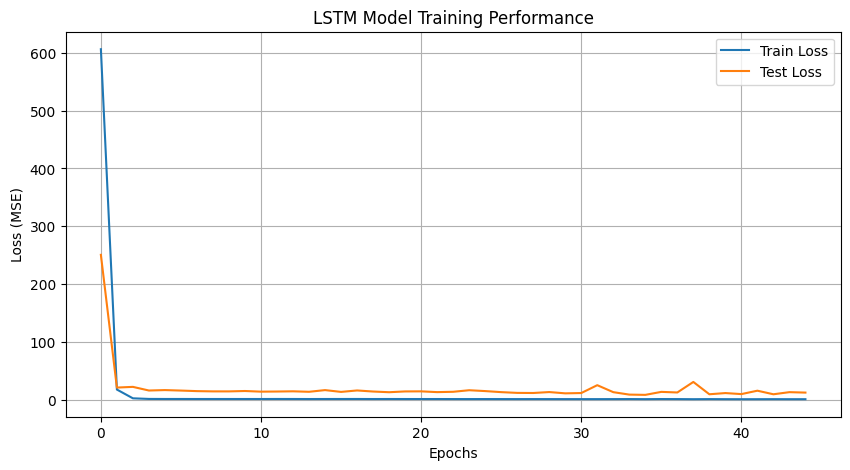

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping

# Train the LSTM model
def train_lstm_model(lstm_model, X_train, y_train, X_test, y_test, epochs=50, batch_size=64):
    # Ensure the data shapes are consistent
    if X_train.shape[0] != y_train.shape[0]:
        raise ValueError(f"Mismatch in samples: X_train has {X_train.shape[0]} samples, but y_train has {y_train.shape[0]} samples.")

    if X_test.shape[0] != y_test.shape[0]:
        raise ValueError(f"Mismatch in samples: X_test has {X_test.shape[0]} samples, but y_test has {y_test.shape[0]} samples.")

    # Fit the model
    history = lstm_model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_test, y_test),
        callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
        verbose=1
    )

    # Plot training performance
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Test Loss')  # Test Loss
    plt.title('LSTM Model Training Performance')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True)
    plt.show()

    return history

lstm_history = train_lstm_model(lstm_model, X_train_supervised, y_train_supervised, X_test_supervised, y_test_supervised, epochs=50, batch_size=64)


# Train the transformer model

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - loss: 1599.8932 - mae: 36.5321 - mape: 94.8754 - val_loss: 1680.0701 - val_mae: 40.0939 - val_mape: 38.7155
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 230.9089 - mae: 11.8154 - mape: 29.9359 - val_loss: 42.8506 - val_mae: 5.5639 - val_mape: 5.3545
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 127.3243 - mae: 8.8901 - mape: 23.5338 - val_loss: 63.9407 - val_mae: 7.1985 - val_mape: 6.9654
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 95.9236 - mae: 7.5283 - mape: 19.7455 - val_loss: 62.1861 - val_mae: 7.0762 - val_mape: 6.8498
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 99.4974 - mae: 7.5625 - mape: 19.9553 - val_loss: 63.3628 - val_mae: 7.1579 - val_mape: 6.9330
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 83.6174 - mae: 6.9523 - mape: 18.7046 - val_loss: 30.8025 - val_mae: 4.6909 - val_mape: 4.5428
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 82.4793

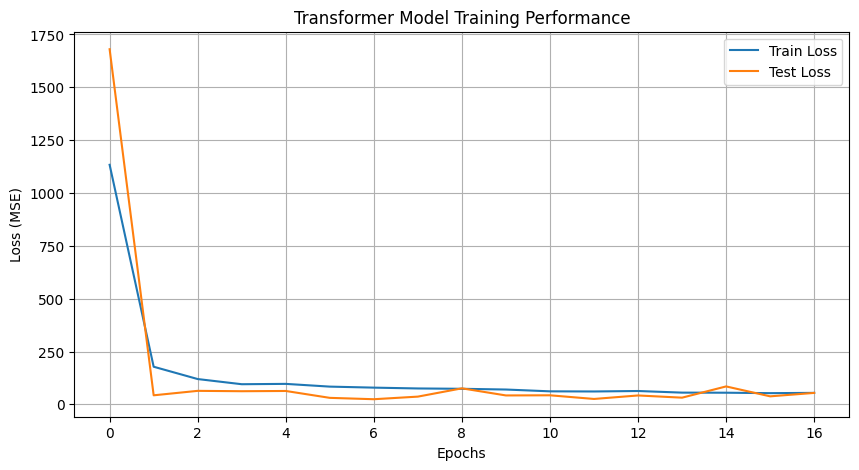

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping

# Train the Transformer model
def train_transformer_model(transformer_model, X_train, y_train, X_test, y_test, epochs=50, batch_size=64):
    # Ensure the data shapes are consistent
    if X_train.shape[0] != y_train.shape[0]:
        raise ValueError(f"Mismatch in samples: X_train has {X_train.shape[0]} samples, but y_train has {y_train.shape[0]} samples.")

    if X_test.shape[0] != y_test.shape[0]:
        raise ValueError(f"Mismatch in samples: X_test has {X_test.shape[0]} samples, but y_test has {y_test.shape[0]} samples.")

    # Fit the model
    history = transformer_model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_test, y_test),
        callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
        verbose=1
    )

    # Plot training performance
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Test Loss')  # Test Loss
    plt.title('Transformer Model Training Performance')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True)
    plt.show()

    return history

# Assuming transformer_model, X_train_supervised, y_train_supervised, X_test_supervised, y_test_supervised are already defined
transformer_history = train_transformer_model(transformer_model, X_train_supervised, y_train_supervised, X_test_supervised, y_test_supervised, epochs=50, batch_size=64)


# Evaluate the models

In [ ]:
import numpy as np
import tensorflow as tf

# Evaluate the LSTM model on the test set
def evaluate_lstm_model(lstm_model, X_test, y_test):
    # Evaluate the model on the test data
    test_loss, test_mae, test_mape = lstm_model.evaluate(X_test, y_test, verbose=0)

    # Print the evaluation results
    print(f"Test Loss (LSTM): {test_loss}")
    print(f"Test MAE (LSTM): {test_mae}")
    print(f"Test MAPE (LSTM): {test_mape}")

    return test_loss, test_mae, test_mape

# Evaluate the Transformer model on the test set
def evaluate_transformer_model(transformer_model, X_test, y_test):
    # Evaluate the model on the test data
    test_loss, test_mae, test_mape = transformer_model.evaluate(X_test, y_test, verbose=0)

    # Print the evaluation results
    print(f"Test Loss (Transformer): {test_loss}")
    print(f"Test MAE (Transformer): {test_mae}")
    print(f"Test MAPE (Transformer): {test_mape}")

    return test_loss, test_mae, test_mape


In [ ]:
evaluate_lstm_model(lstm_model, X_test_supervised, y_test_supervised)

Test Loss (LSTM): 8.452265739440918
Test MAE (LSTM): 2.08408522605896
Test MAPE (LSTM): 2.007051467895508


(8.452265739440918, 2.08408522605896, 2.007051467895508)

In [ ]:
evaluate_transformer_model(transformer_model, X_test_supervised, y_test_supervised)

Test Loss (Transformer): 24.337007522583008
Test MAE (Transformer): 4.051804065704346
Test MAPE (Transformer): 3.9270126819610596


(24.337007522583008, 4.051804065704346, 3.9270126819610596)

In [ ]:
# Function to evaluate the LSTM model and get predictions
def evaluate_and_predict_lstm(lstm_model, X_test, y_test):
    # Evaluate the model on the test data
    test_loss, test_mae, test_mape = lstm_model.evaluate(X_test, y_test, verbose=0)

    # Print the evaluation results
    print(f"Test Loss (LSTM): {test_loss}")
    print(f"Test MAE (LSTM): {test_mae}")
    print(f"Test MAPE (LSTM): {test_mape}")

    # Make predictions on the test set
    predictions_lstm = lstm_model.predict(X_test)

    return predictions_lstm  # Return only predictions, not a tuple

# Function to evaluate the Transformer model and get predictions
def evaluate_and_predict_transformer(transformer_model, X_test, y_test):
    # Evaluate the model on the test data
    test_loss, test_mae, test_mape = transformer_model.evaluate(X_test, y_test, verbose=0)

    # Print the evaluation results
    print(f"Test Loss (Transformer): {test_loss}")
    print(f"Test MAE (Transformer): {test_mae}")
    print(f"Test MAPE (Transformer): {test_mape}")

    # Make predictions on the test set
    predictions_transformer = transformer_model.predict(X_test)

    return predictions_transformer  # Return only predictions, not a tuple


Test Loss (LSTM): 8.452265739440918
Test MAE (LSTM): 2.08408522605896
Test MAPE (LSTM): 2.007051467895508
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


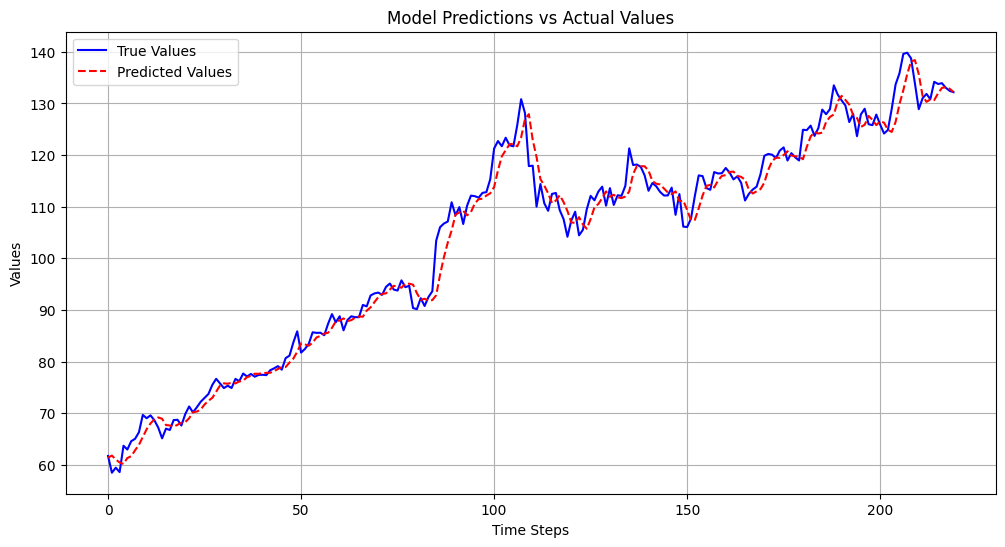

Test Loss (Transformer): 24.337007522583008
Test MAE (Transformer): 4.051804065704346
Test MAPE (Transformer): 3.9270126819610596
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step


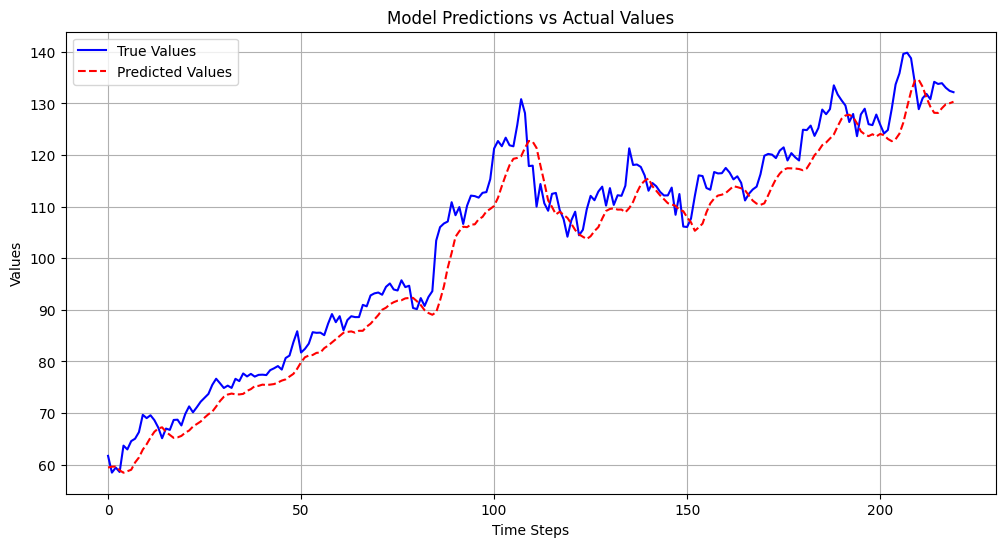

In [ ]:
# Plot the predictions vs actual values
def plot_predictions_vs_actual(predictions, true_values, num_points=500):
    # Flatten predictions and true values for easier plotting
    predictions_flat = predictions.flatten()
    true_values_flat = true_values.flatten()

    # Plot the predictions vs actual values
    plt.figure(figsize=(12, 6))
    plt.plot(true_values_flat[:num_points], label='True Values', color='blue')
    plt.plot(predictions_flat[:num_points], label='Predicted Values', color='red', linestyle='--')
    plt.legend()
    plt.title('Model Predictions vs Actual Values')
    plt.xlabel('Time Steps')
    plt.ylabel('Values')
    plt.grid(True)
    plt.show()

# Get predictions for LSTM model
predictions_lstm = evaluate_and_predict_lstm(lstm_model, X_test_supervised, y_test_supervised)

# Plot the LSTM predictions vs actual values
plot_predictions_vs_actual(predictions_lstm, y_test_supervised)

# Get predictions for Transformer model
predictions_transformer = evaluate_and_predict_transformer(transformer_model, X_test_supervised, y_test_supervised)

# Plot the Transformer predictions vs actual values
plot_predictions_vs_actual(predictions_transformer, y_test_supervised)


In [ ]:
X_test_supervised.shape

(216, 5, 1)